In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras import datasets

In [2]:
f_mnist = datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels) = f_mnist.load_data()

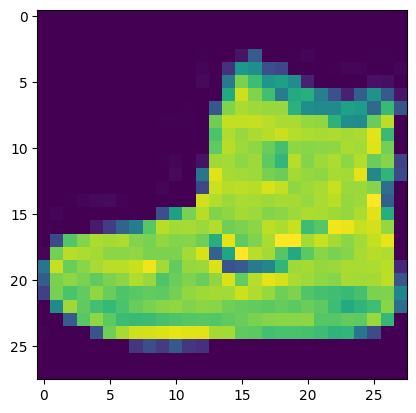

In [3]:
plt.imshow(train_images[0])

In [4]:
train_images=train_images/255.0
teat_images=test_images/255.0

In [5]:
model =Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [6]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [7]:
model.fit(train_images,train_labels,epochs=30)

Epoch 1/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4967 - accuracy: 0.8264
Epoch 2/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3739 - accuracy: 0.8650
Epoch 3/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3347 - accuracy: 0.8774
Epoch 4/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3130 - accuracy: 0.8846
Epoch 5/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2939 - accuracy: 0.8926
Epoch 6/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2801 - accuracy: 0.8959
Epoch 7/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2684 - accuracy: 0.9004
Epoch 8/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2579 - accuracy: 0.9044
Epoch 9/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2459 - accuracy: 0.9075
Epoch 10/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.239

In [8]:
loss, acc = model.evaluate(test_images,test_labels)
print("정확도 :",acc*100)

313/313 [==============================] - 1s 2ms/step - loss: 97.2197 - accuracy: 0.8560
정확도 : 85.6000006198883


In [31]:
from PIL import Image

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

img = Image.open('test/clothes/image07.png').convert('L')
img = img.resize((28,28))

img_data = np.array(img)/255.0
img_data = 1.0-img_data

img_data = np.expand_dims(img_data,axis=0)

In [28]:
# 예측하기_01

pred = model.predict(img_data)
ix = np.argmax(pred[0])
print("확률 모음집 :",pred)

1/1 [==============================] - 0s 13ms/step
확률 모음집 : [[6.2331922e-02 1.4559118e-03 9.6556516e-03 7.6091456e-01 9.8174415e-04
  1.8137743e-03 1.6169512e-01 5.9593771e-05 9.4880798e-04 1.4282722e-04]]


In [29]:
# 예측하기_02

pred = model.predict(img_data)
ix = np.argmax(pred[0])
p = np.max(pred[0])*100
pred_label= class_names[ix]
print('예측 결과 : ',pred_label)
print('예측 확률 : ',p)

1/1 [==============================] - 0s 21ms/step
예측 결과 :  Dress
예측 확률 :  76.09145641326904


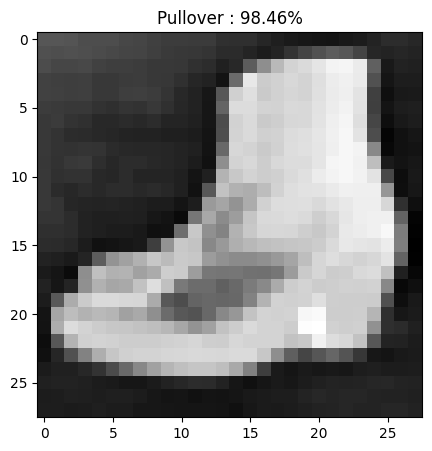

In [34]:
plt.figure(figsize=(5,5))
plt.imshow(img_data[0],cmap='gray')
plt.title(f"{pred_label} : {p:.2f}%")
plt.show()